## Causal Imputation for Consistent Weight Estimates

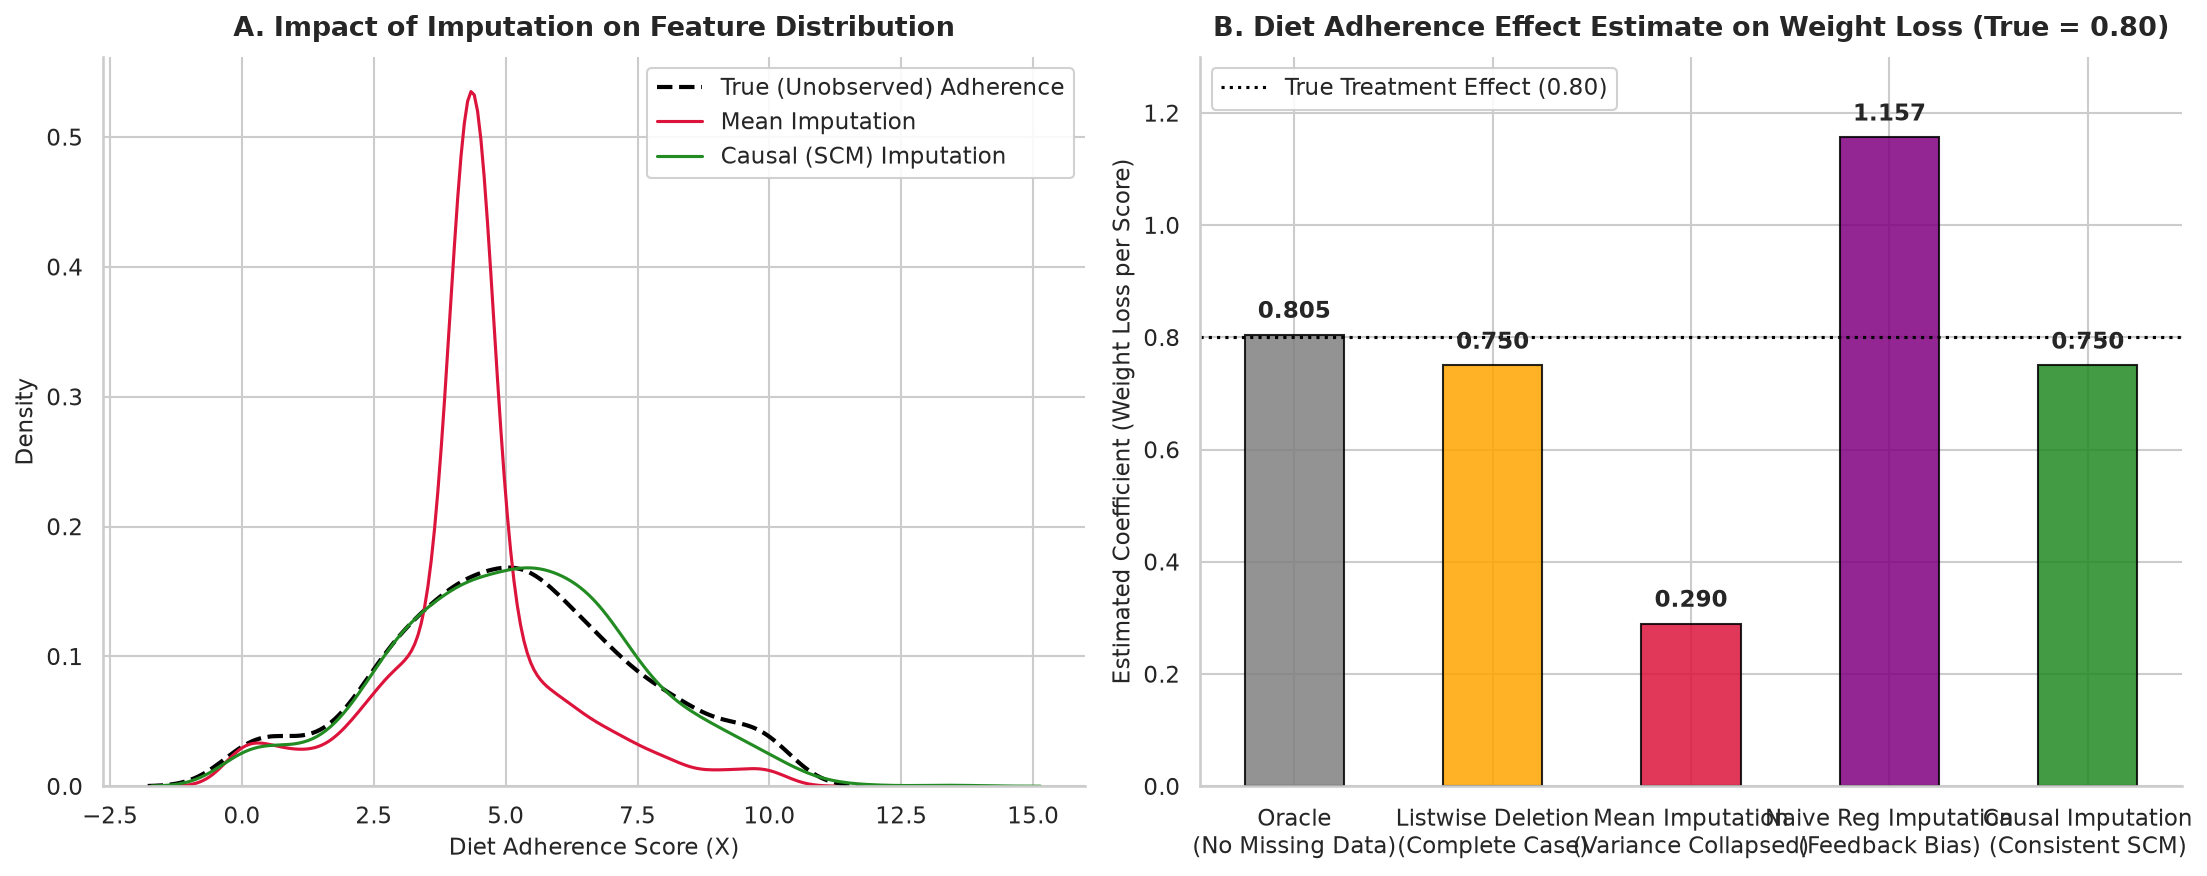

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Set plotting style
sns.set_theme(style='whitegrid', palette='colorblind', font='DejaVu Sans')
plt.rcParams['figure.dpi'] = 150

# 1. Simulate Confounded Weight Loss System with Missing Data

np.random.seed(42)
N = 1000

# Confounder Z: Baseline initial weight/health consciousness
Z = np.random.normal(100, 15, N)  # mean 100kg, std 15kg

# Treatment X: Diet adherence score (0 to 10), caused by initial weight Z
# Sicker/heavier patients are more motivated to adhere to a diet
X_true = 0.15 * (Z - 100) + 5 + np.random.normal(0, 1.2, N)
X_true = np.clip(X_true, 0, 10)

# Outcome Y: Weight loss (kg). True causal effect of diet is beta_X = 0.8
# Baseline weight Z also independently causes weight loss (heavier people lose more baseline weight)
Y = 0.8 * X_true + 0.12 * (Z - 100) + np.random.normal(0, 1.5, N)

# Missingness Mechanism on Diet Adherence (X)
# Missingness is MAR (Missing at Random) caused by baseline weight Z
# Heavier/sicker people (high Z) are more self-conscious and less likely to report diet scores
prob_missing = 1 / (1 + np.exp(-0.08 * (Z - 105)))
missing_mask = np.random.uniform(0, 1, N) < prob_missing

X_obs = X_true.copy()
X_obs[missing_mask] = np.nan

df = pd.DataFrame({'X_true': X_true, 'X': X_obs, 'Y': Y, 'Z': Z})


# 2. Implement Imputation / Missing Data Handling Strategies

missing_idx = df['X'].isna()

# A. Complete Data (Oracle - Benchmark)
model_oracle = LinearRegression()
model_oracle.fit(df[['X_true', 'Z']], df['Y'])
coef_oracle = model_oracle.coef_[0]

# B. Listwise Deletion (Naive Complete Case Analysis)
df_cc = df.dropna()
model_cc = LinearRegression()
model_cc.fit(df_cc[['X', 'Z']], df_cc['Y'])
coef_cc = model_cc.coef_[0]

# C. Naive Mean Imputation
df_mean = df.copy()
df_mean['X'] = df_mean['X'].fillna(df_mean['X'].mean())
model_mean = LinearRegression()
model_mean.fit(df_mean[['X', 'Z']], df_mean['Y'])
coef_mean = model_mean.coef_[0]

# D. Naive Regression Imputation (Predicting X from Y only)
df_reg_naive = df.copy()
reg_naive_fit = LinearRegression().fit(df[~missing_idx][['Y']], df[~missing_idx]['X'])
df_reg_naive.loc[missing_idx, 'X'] = reg_naive_fit.predict(df_reg_naive[missing_idx][['Y']])
model_reg_naive = LinearRegression()
model_reg_naive.fit(df_reg_naive[['X', 'Z']], df_reg_naive['Y'])
coef_reg_naive = model_reg_naive.coef_[0]

# E. Causal Imputation (SCM-based, predicting X from parent Z)
df_causal = df.copy()
reg_causal_fit = LinearRegression().fit(df[~missing_idx][['Z']], df[~missing_idx]['X'])
df_causal.loc[missing_idx, 'X'] = reg_causal_fit.predict(df_causal[missing_idx][['Z']])
model_causal = LinearRegression()
model_causal.fit(df_causal[['X', 'Z']], df_causal['Y'])
coef_causal = model_causal.coef_[0]


# 3. Generate Publication-Quality Visuals

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ---- Panel A: Distribution of Adherence (X) under different methods ----
sns.kdeplot(df['X_true'], label='True (Unobserved) Adherence', color='black', linewidth=2, linestyle='--', ax=ax1)
sns.kdeplot(df_mean['X'], label='Mean Imputation', color='crimson', linewidth=1.5, ax=ax1)
sns.kdeplot(df_causal['X'], label='Causal (SCM) Imputation', color='forestgreen', linewidth=1.5, ax=ax1)
ax1.set_title("A. Impact of Imputation on Feature Distribution", fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel("Diet Adherence Score (X)", fontsize=11)
ax1.set_ylabel("Density", fontsize=11)
ax1.legend(frameon=True, facecolor='white', framealpha=0.9)

# ---- Panel B: Coefficient Estimation Bias Comparison ----
methods = [
    'Oracle\n(No Missing Data)', 
    'Listwise Deletion\n(Complete Case)', 
    'Mean Imputation\n(Variance Collapsed)', 
    'Naive Reg Imputation\n(Feedback Bias)', 
    'Causal Imputation\n(Consistent SCM)'
]
estimates = [coef_oracle, coef_cc, coef_mean, coef_reg_naive, coef_causal]
colors = ['gray', 'orange', 'crimson', 'purple', 'forestgreen']

bars = ax2.bar(methods, estimates, color=colors, alpha=0.85, edgecolor='black', width=0.5)
ax2.axhline(0.8, color='black', linestyle=':', linewidth=1.5, label='True Treatment Effect (0.80)')

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02, 
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax2.set_title("B. Diet Adherence Effect Estimate on Weight Loss (True = 0.80)", fontsize=13, fontweight='bold', pad=10)
ax2.set_ylabel("Estimated Coefficient (Weight Loss per Score)", fontsize=11)
ax2.set_ylim(0, 1.3)
ax2.legend(frameon=True, facecolor='white', framealpha=0.9)

sns.despine()
plt.tight_layout()
plt.show()